#  Library And Data Importing 

In [28]:
# General Use Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns 

# Preprocessing Modules
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Model Building Modules
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.calibration import CalibratedClassifierCV

# Model Evaluation Modules 
from sklearn.metrics import roc_auc_score, confusion_matrix

# Model Loading Modules
import joblib

In [29]:
data = pd.read_csv('../data/cleaned_data.csv')
data.head()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,BMXBMI,LBXGH,DIQ010,LBXGLU,SBP_mean,LBDHDD,LBXSCR,ACR,diabetes_label,LBXGH_missing,HDL_missing,ACR_missing,LBXGLU_missing
0,109266.0,29.0,2.0,6.0,37.8,5.2,2.0,103.0,99.000000,56.0,0.63,0.152778,0,0,0,0,1
1,109267.0,21.0,2.0,2.0,28.6,5.6,2.0,103.0,121.333333,51.0,0.84,0.075926,0,1,1,1,1
2,109268.0,18.0,2.0,3.0,28.6,5.6,2.0,103.0,121.333333,51.0,0.84,0.075926,0,1,1,1,1
3,109271.0,49.0,1.0,3.0,29.7,5.6,2.0,103.0,107.000000,33.0,0.78,0.075000,0,0,0,0,0
4,109273.0,36.0,1.0,3.0,21.9,5.1,2.0,103.0,113.666667,42.0,0.92,0.040496,0,0,0,0,1


# Model Building 

In [30]:
X = data.drop(['diabetes_label', 'SEQN', 'DIQ010'], axis = 1)
y = data['diabetes_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)
print(f"Train Data Shape: {X_train.shape}")
print(f"Test Data Shape: {X_test.shape}")

Train Data Shape: (7754, 14)
Test Data Shape: (1939, 14)


In [31]:
categorical_features = ["RIAGENDR", "RIDRETH3"]
numerical_features = [
    "RIDAGEYR",
    "BMXBMI",
    "LBXGH", "LBXGH_missing",
    "SBP_mean",
    "LBDHDD", "HDL_missing",
    "LBXSCR",
    "LBXGLU", "LBXGLU_missing",
    "ACR", "ACR_missing",
]
print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['RIDAGEYR', 'BMXBMI', 'LBXGH', 'LBXGH_missing', 'SBP_mean', 'LBDHDD', 'HDL_missing', 'LBXSCR', 'LBXGLU', 'LBXGLU_missing', 'ACR', 'ACR_missing']
Categorical Features: ['RIAGENDR', 'RIDRETH3']


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [33]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'XGBoost' : XGBClassifier()
}
results = {}
pipelines = {
    name : Pipeline([
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    for name, model in models.items()
}
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    results[name] = auc
print(results)


{'Random Forest': 0.9517424849956242, 'Logistic Regression': 0.9543671064532548, 'XGBoost': 0.9502145836308576}


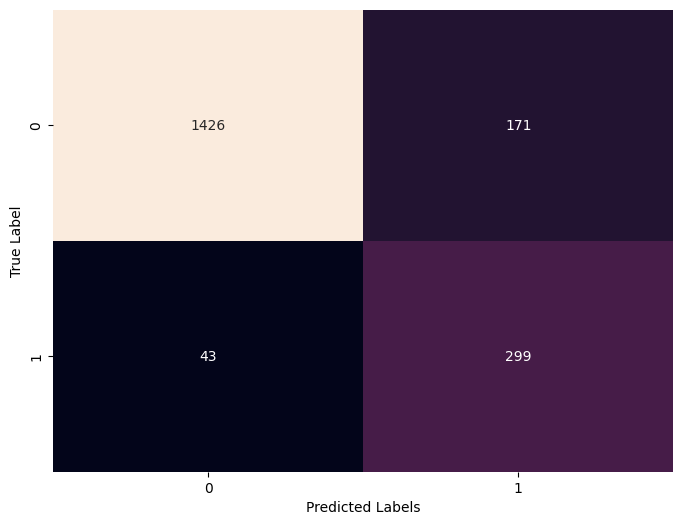

In [34]:
final_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
final_model.fit(X_train, y_train)
cm = confusion_matrix(y_test, final_model.predict(X_test))
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.heatmap(cm, annot=True, fmt = 'd', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Label')
plt.show()

In [35]:
pre = final_model.named_steps["preprocessing"]
num_names = pre.named_transformers_["num"].get_feature_names_out(numerical_features)
cat_names = pre.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([num_names, cat_names])
len(feature_names), feature_names[:10]

(20,
 array(['RIDAGEYR', 'BMXBMI', 'LBXGH', 'LBXGH_missing', 'SBP_mean',
        'LBDHDD', 'HDL_missing', 'LBXSCR', 'LBXGLU', 'LBXGLU_missing'],
       dtype=object))

In [36]:
coef = final_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
}).sort_values(by="coefficient", ascending=False)
coef_df

,feature,coefficient
2,LBXGH,3.596174
8,LBXGLU,0.843388
0,RIDAGEYR,0.804424
1,BMXBMI,0.340394
3,LBXGH_missing,0.283050
10,ACR,0.199509
7,LBXSCR,0.148178
11,ACR_missing,0.140540
6,HDL_missing,0.132879
9,LBXGLU_missing,0.126721


In [37]:
y_proba_raw = final_model.predict_proba(X_test)[:, 1]
y_proba_raw[:10]

array([7.49269316e-02, 9.63861891e-01, 5.78765093e-02, 1.72448591e-01,
       3.64617180e-04, 3.94987498e-01, 1.04215223e-01, 2.33480728e-03,
       1.57641244e-01, 9.99347543e-01])

In [38]:
calibrated_model = CalibratedClassifierCV(estimator=final_model, method="sigmoid", cv=5)
calibrated_model.fit(X_train, y_train)
y_proba_raw = final_model.predict_proba(X_test)[:, 1]
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]

print("Raw ROC-AUC:", roc_auc_score(y_test, y_proba_raw))
print("Calibrated ROC-AUC:", roc_auc_score(y_test, y_proba_cal))

Raw ROC-AUC: 0.9543671064532548
Calibrated ROC-AUC: 0.9544092175753514


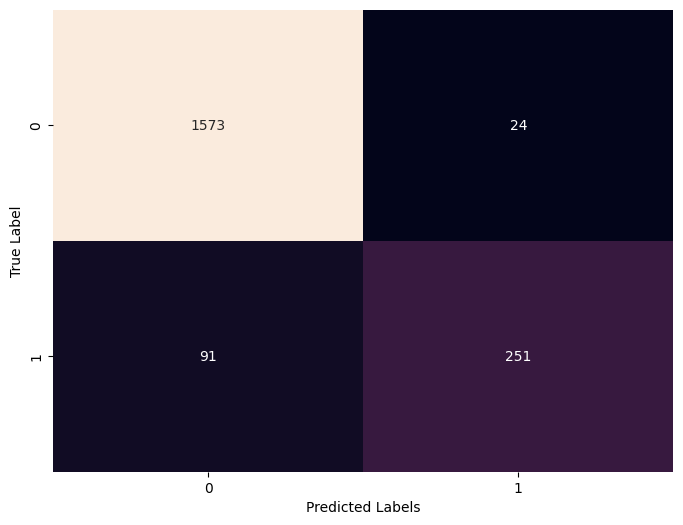

In [39]:
cm = confusion_matrix(y_test, calibrated_model.predict(X_test))
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.heatmap(cm, annot=True, fmt = 'd', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Label')
plt.show()

In [40]:
def risk_category(p):
    if p < 0.35:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

In [41]:
risk_df = X_test.copy()
risk_df["true_label"] = y_test.values
risk_df["risk_proba"] = y_proba_cal
risk_df["risk_category"] = risk_df["risk_proba"].apply(risk_category)

risk_df["risk_category"].value_counts()


risk_category
Low       1616
High       223
Medium     100
Name: count, dtype: int64

In [42]:
y_test.value_counts()

diabetes_label
0    1597
1     342
Name: count, dtype: int64

In [43]:
pd.crosstab(
    risk_df["risk_category"],
    risk_df["true_label"],
    normalize="index"
).round(3)

true_label,0,1
risk_category,,
High,0.018,0.982
Low,0.954,0.046
Medium,0.520,0.480


In [44]:
joblib.dump(calibrated_model, '../models/calibrated_Logistic_regression_model.joblib')

['../models/calibrated_Logistic_regression_model.joblib']

In [45]:
joblib.dump(list(X.columns), '../models/calibrated_Logistic_regression_model_feature_columns.joblib')
joblib.dump({"low": 0.35, "high": 0.70}, '../models/calibrated_Logistic_regression_model_risk_thresholds.joblib')

['../models/calibrated_Logistic_regression_model_risk_thresholds.joblib']